In [1]:
"""
Per-image SigLIP2 text embedding generation.

Reads a CSV with per-image captions, encodes each caption with the
SigLIP2 text encoder, L2-normalises, and saves a single .pt dict.

Supports two keying strategies controlled by KEY_BY_PID:
  - True  → {pid (int): tensor(768,)}       one embedding per identity
  - False → {"filename.jpg": tensor(768,)}  one embedding per image

Usage:  Edit the configuration variables below and run directly
        or paste into a notebook cell.
"""

import torch
import torch.nn.functional as F
import pandas as pd
from typing import Dict, Union
from transformers import AutoTokenizer, AutoModel

# ── Configuration (edit these) ────────────────────────────────────────
CSV_PATH   = "/kaggle/input/datasets/davidmagdy/qwen3-descriptions/qwen3_descriptions.csv"
OUTPUT_PT  = "/kaggle/working/market1501_cpi_embeddings.pt"
BATCH_SIZE = 64
MODEL_ID   = "google/siglip2-base-patch16-224"
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

# Keying strategy
KEY_BY_PID    = True                # True = per-identity (PID); False = per-image (filename)
PID_COLUMN    = "person_id"          # column name for PID  (used when KEY_BY_PID=True)
FNAME_COLUMN  = "filename"           # column name for filename (used when KEY_BY_PID=False)
TEXT_COLUMN   = "description"
# ──────────────────────────────────────────────────────────────────────

# ── Load model ────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()

# Grab the text tower if the model exposes one
text_model = getattr(model, "text_model", model)

# ── Read CSV ──────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
assert TEXT_COLUMN in df.columns, f"CSV must contain column '{TEXT_COLUMN}'"

if KEY_BY_PID:
    assert PID_COLUMN in df.columns, f"CSV must contain column '{PID_COLUMN}'"
    # One embedding per identity — keep first description per PID
    df = df.drop_duplicates(subset=[PID_COLUMN])
    keys = [int(row[PID_COLUMN]) for _, row in df.iterrows()]
    print(f"Mode: per-identity (PID). {len(df)} unique identities.")
else:
    assert FNAME_COLUMN in df.columns, f"CSV must contain column '{FNAME_COLUMN}'"
    keys = [str(row[FNAME_COLUMN]).strip() for _, row in df.iterrows()]
    print(f"Mode: per-image (filename). {len(df)} images.")

texts = [str(row[TEXT_COLUMN]) for _, row in df.iterrows()]

# Filter out rows with empty captions
valid = [(k, t) for k, t in zip(keys, texts) if t.strip()]
skipped = len(keys) - len(valid)
keys = [v[0] for v in valid]
texts = [v[1] for v in valid]
print(f"Valid captions: {len(keys)}, skipped (empty): {skipped}")

# ── Batched inference ─────────────────────────────────────────────────
embeddings: Dict[Union[int, str], torch.Tensor] = {}

with torch.no_grad():
    for start in range(0, len(keys), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(keys))
        batch_keys = keys[start:end]
        batch_texts = texts[start:end]

        tokens = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=64,
        ).to(DEVICE)

        outputs = text_model(**tokens)

        # Use pooler_output if available, otherwise mean-pool last_hidden_state
        if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
            embs = outputs.pooler_output                   # (B, D)
        else:
            embs = outputs.last_hidden_state.mean(dim=1)   # (B, D)

        embs = F.normalize(embs, dim=-1)                   # L2-normalise

        for key, emb in zip(batch_keys, embs.cpu()):
            embeddings[key] = emb                          # shape: (768,)

        if (start // BATCH_SIZE) % 10 == 0:
            print(f"  Processed {end}/{len(keys)} ...")

# ── Save ──────────────────────────────────────────────────────────────
torch.save(embeddings, OUTPUT_PT)

print(f"\n{'='*50}")
print(f"Saved {len(embeddings)} embeddings → {OUTPUT_PT}")
print(f"Sample keys: {list(embeddings.keys())[:5]}")
if skipped:
    print(f"Skipped {skipped} rows (empty caption)")


config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Mode: per-identity (PID). 1501 unique identities.
Valid captions: 1501, skipped (empty): 0
  Processed 64/1501 ...
  Processed 704/1501 ...
  Processed 1344/1501 ...

Saved 1501 embeddings → /kaggle/working/market1501_cpi_embeddings.pt
Sample keys: [1, 2, 3, 4, 5]


Loaded 75 embeddings (sampled from 1501), shape (75, 768)
PCA -> 50 dims done


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done; shape: (75, 2)


/tmp/ipykernel_57/2658233508.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.scatterplot(


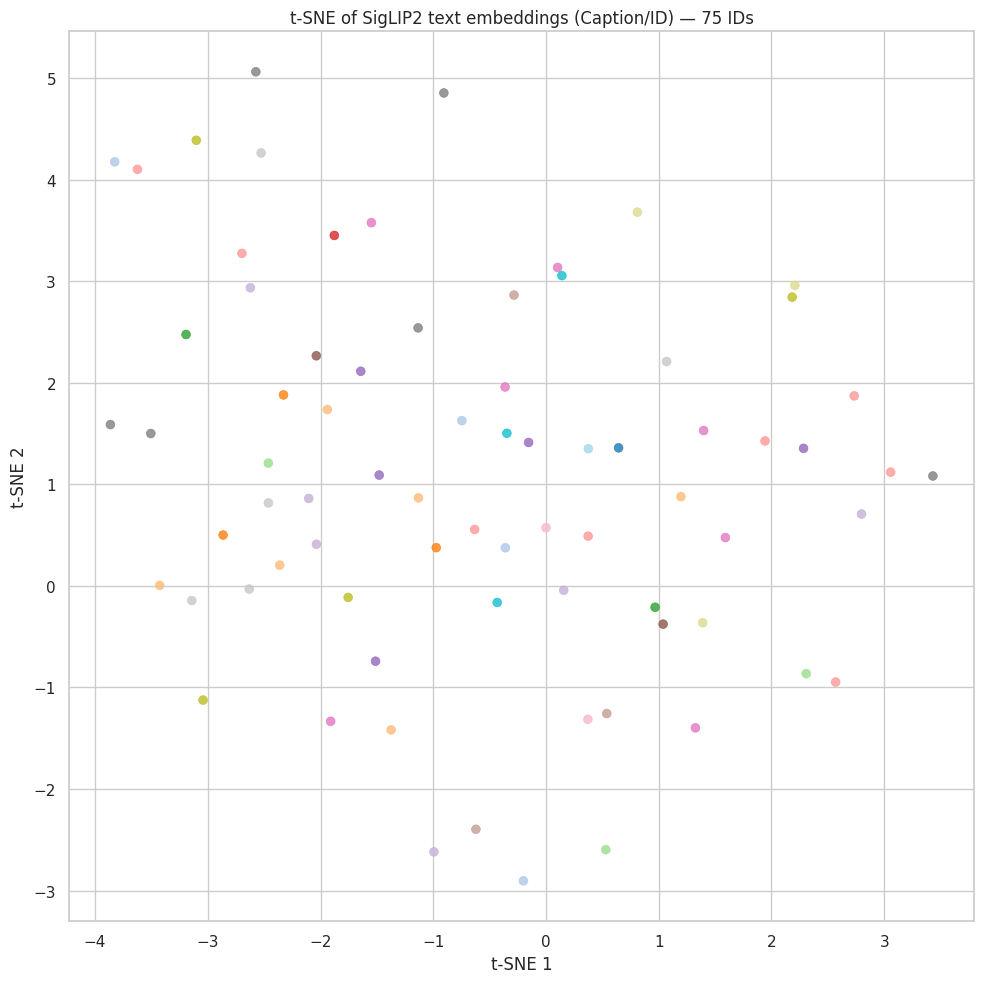

In [2]:
# t-SNE visualization for saved embeddings
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import random

# Config
EMBEDDING_PT = OUTPUT_PT            # path used in your script
TSNE_PERPLEXITY = 30                # try 5-50; adjust for dataset size
TSNE_N_ITER = 1000                  # increase for stability
TSNE_RANDOM_STATE = 0
ANNOTATE_SAMPLE_PER_LABEL = 0       # 0 to disable
FIGSIZE = (10, 10)
PALETTE = "tab20"                   # seaborn palette
N_SAMPLES = 75                      # number of random IDs to load

# Load embeddings (dict: key -> tensor)
emb_dict = torch.load(EMBEDDING_PT, map_location="cpu")
all_keys = list(emb_dict.keys())

# Randomly sample N_SAMPLES keys (or all of them if fewer than N_SAMPLES exist)
random.seed(TSNE_RANDOM_STATE)
n_to_sample = min(N_SAMPLES, len(all_keys))
keys = random.sample(all_keys, n_to_sample)

embs = torch.stack([emb_dict[k] for k in keys]).numpy()   # (N, D)
print(f"Loaded {len(keys)} embeddings (sampled from {len(all_keys)}), shape {embs.shape}")

# Optionally reduce dimensionality with PCA first for speed (common practice)
from sklearn.decomposition import PCA
pca_components = min(50, len(keys) - 1, embs.shape[1])  # guard against N < 50
pca = PCA(n_components=pca_components, random_state=TSNE_RANDOM_STATE)
embs_50 = pca.fit_transform(embs)
print(f"PCA -> {pca_components} dims done")

# Run t-SNE (fit_transform) on PCA outputs; scikit-learn TSNE recommended workflow [web:1][web:8]
tsne_perplexity = min(TSNE_PERPLEXITY, len(keys) - 1)  # perplexity must be < n_samples
tsne = TSNE(
    n_components=2,
    perplexity=tsne_perplexity,
    n_iter=TSNE_N_ITER,
    random_state=TSNE_RANDOM_STATE,
    init="pca",        # faster/more stable init
    learning_rate="auto",
)
pts2d = tsne.fit_transform(embs_50)
print("t-SNE done; shape:", pts2d.shape)

# Prepare a DataFrame for plotting
import pandas as pd
df_vis = pd.DataFrame({
    "x": pts2d[:, 0],
    "y": pts2d[:, 1],
    "key": keys,
})

# If keys are numeric PIDs, convert to str for plotting/hue
df_vis["label"] = df_vis["key"].astype(str)

# Plot
plt.figure(figsize=FIGSIZE)
sns.set(style="whitegrid")
unique_labels = df_vis["label"].nunique()
palette = sns.color_palette(PALETTE, min(unique_labels, 20))
ax = sns.scatterplot(
    data=df_vis,
    x="x", y="y",
    hue="label" if unique_labels <= 20 else None,  # only hue if labels <= palette size
    palette=palette,
    legend="brief" if unique_labels <= 20 else False,
    s=40,
    alpha=0.8,
)
ax.set_title("t-SNE of SigLIP2 text embeddings (Caption/ID) — 75 IDs")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# If many labels, add color by hashing label -> color (deterministic)
if unique_labels > 20:
    # color points deterministically by hash of key
    colors = [palette[hash(k) % len(palette)] for k in df_vis["key"]]
    ax.collections[0].set_color(colors)

# Annotate a small sample per label (optional)
if ANNOTATE_SAMPLE_PER_LABEL > 0:
    grouped = df_vis.groupby("label")
    to_annotate = []
    for lbl, group in grouped:
        sample_n = min(len(group), ANNOTATE_SAMPLE_PER_LABEL)
        to_annotate.append(group.sample(sample_n, random_state=TSNE_RANDOM_STATE))
    if to_annotate:
        ann = pd.concat(to_annotate)
        for _, row in ann.iterrows():
            ax.text(row["x"] + 0.5, row["y"] + 0.5, str(row["key"]), fontsize=8)

plt.tight_layout()
plt.savefig("tsne_embeddings.svg", dpi=300, bbox_inches="tight")
plt.show()